# Rede Neural

Imports

In [64]:
from src.objetos import Dados, camada_densa, rede_neural

Caminho contendo os dados das imagens e os rótulos correspondentes.

In [65]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

Inicialização dos dados

In [66]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

Método de separação dos dados

In [67]:
dados._holdout(0.6, 0.2)

Parâmetros da rede neural

In [68]:
epocas = 500
taxa_aprendizado = 2
lambda_reg = 1.0
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]

Inicialização das camadas

In [69]:
camadas = []

for i in range(len(arquitetura_camadas)-2):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='sigmoid'
        )
    camadas.append(camada)
# Aplica softmax na ultima camada
camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[-2], 
        tamanho_saida=arquitetura_camadas[-1],
        funcao_de_ativacao='softmax'
        )
camadas.append(camada)


Inicialização da rede neural

In [70]:
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

Treinamento da rede

In [71]:
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg
)

Leitura dos Logs

In [72]:
import pandas as pd

logs = pd.read_csv("log_treinamento.csv")

# Resultado

Acurácia com base no conjunto de teste

In [73]:
import numpy as np
y_teste = rede._avalia(dados.conjunto_teste[0])
classes_pred = np.argmax(y_teste, axis=0) + 1
classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
acertos = np.sum(classes_pred == classes_real)
num_amostras = dados.conjunto_teste[0].shape[1]

acuracia_modelo = acertos/num_amostras

print(acuracia_modelo)

0.917


In [77]:
y_treino = rede._avalia(dados.conjunto_treinamento[0])
y_valida = rede._avalia(dados.conjunto_validacao[0])
y_teste = rede._avalia(dados.conjunto_teste[0])

print(rede._calcula_custo(dados.conjunto_treinamento[1],y_treino))
print(rede._calcula_custo(dados.conjunto_validacao[1],y_valida))
print(rede._calcula_custo(dados.conjunto_teste[1],y_teste))

0.22221797366601775
0.6256237184741991
0.5543119906126512


Imagens do conjunto de teste classificadas incorretamente

In [75]:
for i in range(num_amostras):
    if (classes_pred[i] != classes_real[i]):
        comparacao = np.all(dados.pacote_dados == dados.conjunto_teste[0].T[i], axis=1)
        indice = np.where(comparacao)[0]
        print(indice)
        print(f"Classe prevista: {classes_pred[i]}")
        print(f"Classe real: {classes_real[i]}")

[3537]
Classe prevista: 1
Classe real: 7
[1113]
Classe prevista: 8
Classe real: 2
[2082]
Classe prevista: 2
Classe real: 4
[2556]
Classe prevista: 2
Classe real: 5
[1645]
Classe prevista: 5
Classe real: 3
[1267]
Classe prevista: 3
Classe real: 2
[3908]
Classe prevista: 4
Classe real: 7
[1876]
Classe prevista: 2
Classe real: 3
[1689]
Classe prevista: 5
Classe real: 3
[142]
Classe prevista: 8
Classe real: 10
[4503]
Classe prevista: 7
Classe real: 9
[4251]
Classe prevista: 5
Classe real: 8
[2574]
Classe prevista: 3
Classe real: 5
[2733]
Classe prevista: 3
Classe real: 5
[1760]
Classe prevista: 5
Classe real: 3
[4149]
Classe prevista: 3
Classe real: 8
[2681]
Classe prevista: 6
Classe real: 5
[4519]
Classe prevista: 7
Classe real: 9
[2958]
Classe prevista: 9
Classe real: 5
[1158]
Classe prevista: 3
Classe real: 2
[4904]
Classe prevista: 4
Classe real: 9
[4062]
Classe prevista: 5
Classe real: 8
[1602]
Classe prevista: 5
Classe real: 3
[1617]
Classe prevista: 9
Classe real: 3
[1087]
Classe pr

Gráfico do custo de treinamento e do custo de validação em função da época de treinamento

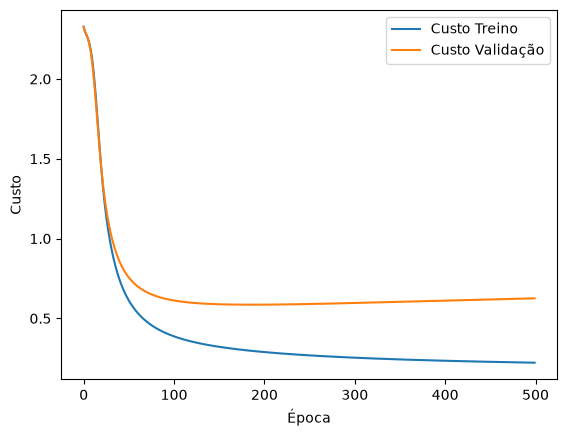

In [76]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["epoca"],logs["custo_treinamento"], label="Custo Treino")
plt.plot(logs["epoca"],logs["custo_validacao"], label="Custo Validação")
plt.xlabel("Época")
plt.ylabel("Custo")
plt.legend()
plt.show()